## Load Sentinel Packages

In [1]:
#Import libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import odc.stac
import pystac_client
from odc.stac import load
from pystac.client import Client
import xarray as xr
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

## Define the study AOI

In [2]:
#Yalelevu AOI imported from asset

aoi = gpd.read_file("/home/jovyan//sentinel-1--sar--analysis/New_Soil_moisture_analysis/Namosau.geojson")
aoi = aoi.to_crs("EPSG:4326")
min_lon, min_lat, max_lon, max_lat = aoi.total_bounds

bbox = [min_lon, min_lat, max_lon, max_lat]

In [3]:
#Display Map
aoi.explore()

## Load Sentinel 1 Data

1. Define the timeframe

In [4]:
catalog = "https://earth-search.aws.element84.com/v1"
client = Client.open(catalog)
datetime = "2024-07-01/2025-06-30"

2. Load the sentinel 1 collection

In [5]:
items = client.search(
    collections=["sentinel-1-grd"],
    bbox=bbox,
    datetime=datetime,
    query={
        "sar:instrument_mode": {"eq": "IW"},
        "sat:orbit_state": {"eq": "ascending"},
        "s1:orbit_source": {"eq": "RESORB"}
    }
).item_collection()

In [6]:
items

3. Loading the VV polarization

In [7]:
ds = odc.stac.load(
items,
bands=["vv", "vh"],
bbox=bbox,
chunks={}
)

In [8]:
print(ds)

<xarray.Dataset> Size: 26MB
Dimensions:      (latitude: 365, longitude: 588, time: 30)
Coordinates:
  * latitude     (latitude) float64 3kB -17.52 -17.52 -17.52 ... -17.56 -17.56
  * longitude    (longitude) float64 5kB 177.6 177.6 177.6 ... 177.7 177.7 177.7
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 240B 2024-07-06T06:40:45.004848 ... 20...
Data variables:
    vv           (time, latitude, longitude) uint16 13MB dask.array<chunksize=(1, 365, 588), meta=np.ndarray>
    vh           (time, latitude, longitude) uint16 13MB dask.array<chunksize=(1, 365, 588), meta=np.ndarray>


In [9]:
# Extract VV backscatter
# Soil moisture studies
# commonly use VV polarization
# ---------------------------
vv = ds["vv"]

4. CONVERT TO dB

In [10]:
# Sentinel-1 backscatter is often analysed in dB.
# Avoid taking log of zero values.
# -----------------------------------------------------------------------------
vv_db = 10 * np.log10(vv.where(vv > 0))

In [11]:
# vv_db: your DataArray (the one you plotted earlier)
vv_mean = vv_db.mean(dim='time', skipna=True)

print("Original vv_mean stats:", float(vv_mean.min()), float(vv_mean.max()), float(vv_mean.mean()))

/srv/conda/envs/notebook/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/srv/conda/envs/notebook/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Original vv_mean stats: 16.332069396972656 38.17599868774414 22.63214111328125


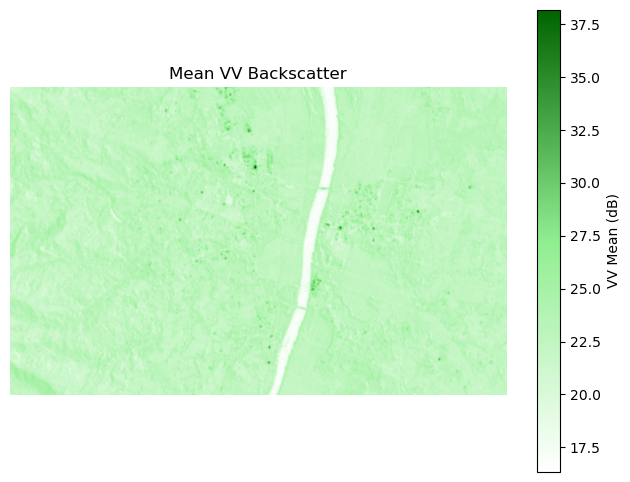

In [12]:
cmap = LinearSegmentedColormap.from_list(
    "water_land",
    ["white", "lightgreen", "darkgreen"]
)

plt.figure(figsize=(8,6))
plt.imshow(vv_mean, cmap=cmap)
plt.colorbar(label='VV Mean (dB)')
plt.title('Mean VV Backscatter')
plt.axis('off')
plt.show()

## Apply Water Mask

In [13]:
#Apply mask
water_mask = vv_mean < 19


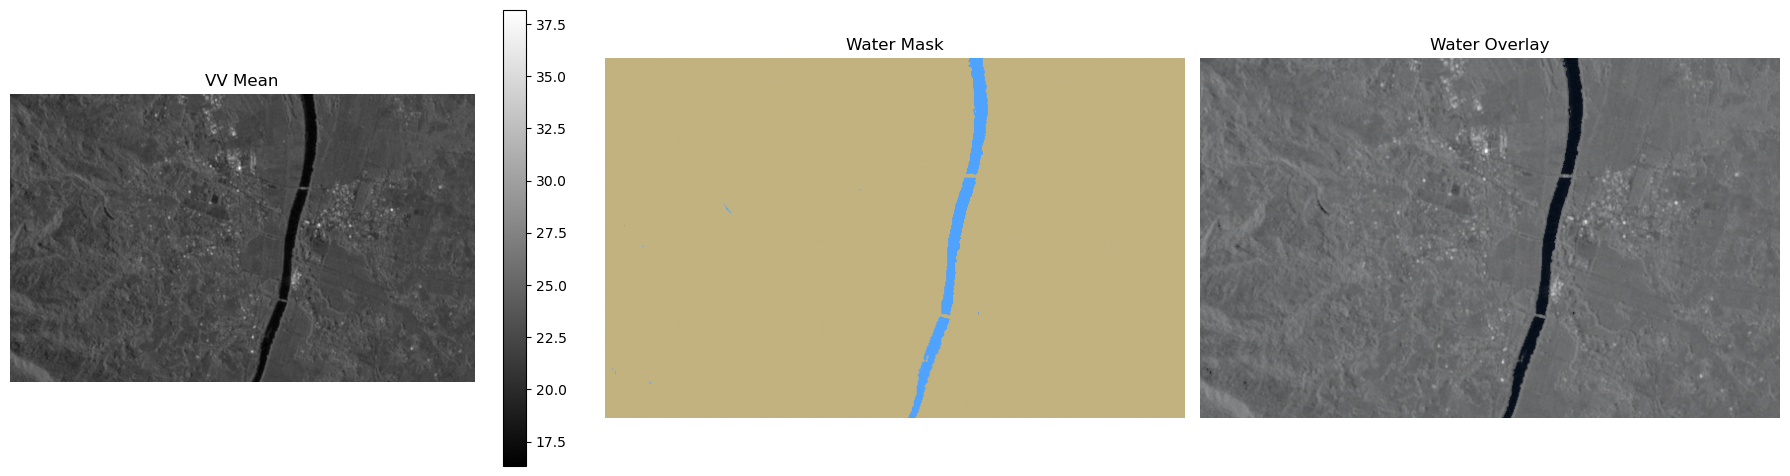

In [14]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# Water mask colours
mask_cmap = ListedColormap([
    '#C2B280',  # land
    '#4FA3FF'         # water
])

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Original VV mean
im = ax[0].imshow(vv_mean, cmap='gray')
ax[0].set_title('VV Mean')
ax[0].axis('off')
plt.colorbar(im, ax=ax[0], shrink=0.8)

# Panel 2: Water mask
ax[1].imshow(water_mask, cmap=mask_cmap)
ax[1].set_title('Water Mask')
ax[1].axis('off')

# Panel 3: VV mean with water overlay
ax[2].imshow(vv_mean, cmap='gray')
ax[2].imshow(water_mask, cmap='Blues', alpha=0.2)
ax[2].set_title('Water Overlay')
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [15]:
print(float(vv_mean.min()))
print(float(vv_mean.max()))
print(float(vv_mean.mean()))

16.332069396972656
38.17599868774414
22.63214111328125


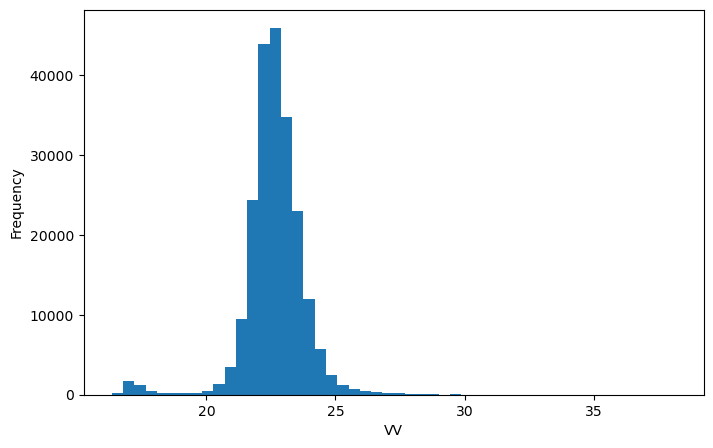

In [16]:
#Plot a histogram
plt.figure(figsize=(8,5))
plt.hist(vv_mean.values.flatten(), bins=50)
plt.xlabel("VV")
plt.ylabel("Frequency")
plt.show()

## Speckle Filtering
- Reduce some noise within the image

In [17]:
import numpy as np
from scipy.ndimage import uniform_filter

def lee_filter(img, size=5):
    """
    Lee speckle filter

    Parameters
    ----------
    img : numpy array
        Input image
    size : int
        Moving window size

    Returns
    -------
    filtered_img : numpy array
    """

    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)

    img_variance = img_sqr_mean - img_mean**2

    overall_variance = np.nanvar(img)

    weights = img_variance / (img_variance + overall_variance)

    filtered_img = img_mean + weights * (img - img_mean)

    return filtered_img

In [18]:
water_vv = vv_mean.where(water_mask)

lee_filtered = lee_filter(
    water_vv.fillna(0).values,
    size=5
)

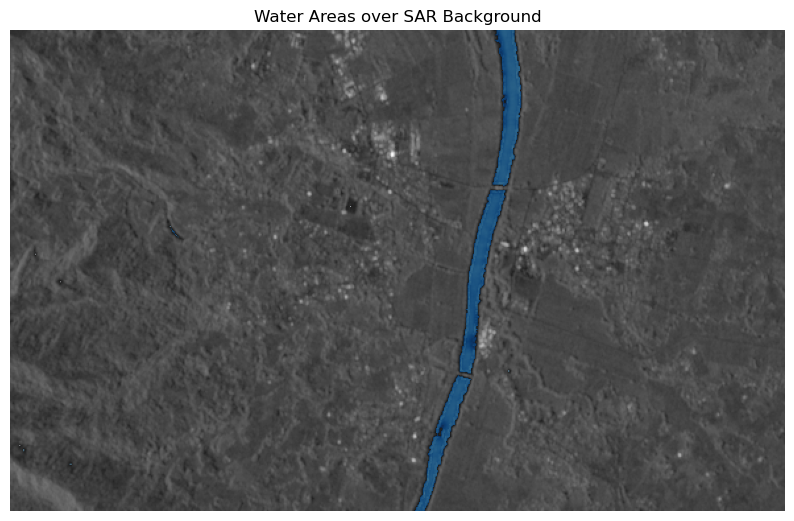

In [23]:
plt.figure(figsize=(10,10))

# Land
plt.imshow(vv_mean, cmap='gray')

# Water overlay
plt.imshow(
    np.where(np.isnan(water_vv), np.nan, lee_filtered),
    cmap='Blues',
    alpha=0.7
)

plt.title('Water Areas over SAR Background')
plt.axis('off')
plt.show()

## DETERMINE DRY  and WET DIFFERENCE CONDITION

1. Dry Difference

2. Wet Difference

In [73]:
land_only = vv_mean.where(~water_mask)

In [74]:
valid_land = land_only.values[
    ~np.isnan(land_only.values)
]

p25 = np.percentile(valid_land, 25)
p75 = np.percentile(valid_land, 75)

wet = land_only < p25
moderate = (land_only >= p25) & (land_only <= p75)
dry = land_only > p75

In [75]:
classification = np.full(vv_mean.shape, np.nan)

classification[dry] = 3
classification[moderate] = 2
classification[wet] = 1

# Force river pixels to wet
classification[water_mask] = 1

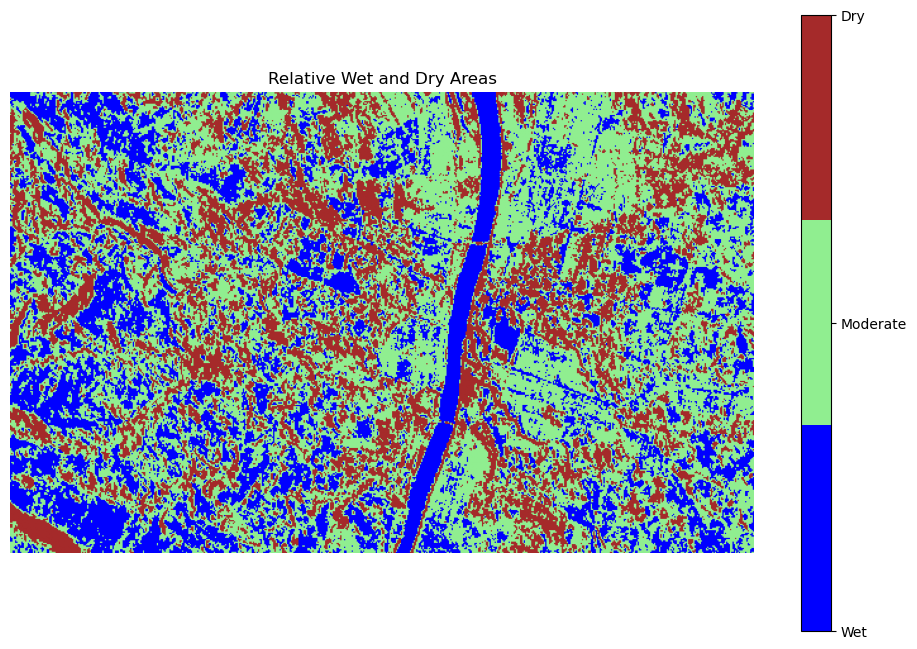

In [76]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "blue",      # wet
    "lightgreen",
    "brown"      # dry
])

plt.figure(figsize=(12,8))
plt.imshow(classification, cmap=cmap)

cbar = plt.colorbar()
cbar.set_ticks([1,2,3])
cbar.set_ticklabels(["Wet","Moderate","Dry"])

plt.title("Relative Wet and Dry Areas")
plt.axis("off")
plt.show()


## DEM
- Masking Elevation above 30- 40m
- Calculate the slope
- Calculate the aspect


In [50]:
from odc.stac import load
from pystac_client import Client

# Open Element84 STAC
e84_catalog = "https://earth-search.aws.element84.com/v1/"
e84_client = Client.open(e84_catalog)

# Search DEM tiles covering your study area
items = e84_client.search(
    collections=["cop-dem-glo-30"],
    bbox=list(ds.odc.geobox.geographic_extent.boundingbox)
).item_collection()

# Load DEM
elevation = load(
    items,
    measurements=["data"],
    geobox=ds.odc.geobox
).squeeze()

In [77]:
lowland_mask = elevation.data < 30   # or 40 m

lowland_vv = vv_mean.where(lowland_mask)

In [78]:
analysis_area = vv_mean.where(lowland_mask & ~water_mask)

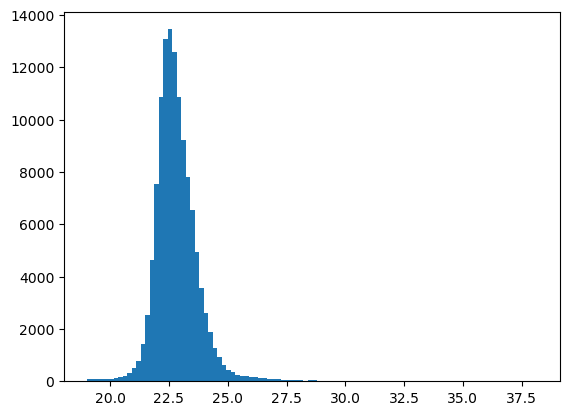

22.273676872253418 23.276887893676758


In [79]:
valid = analysis_area.values[
    ~np.isnan(analysis_area.values)
]

plt.hist(valid, bins=100)
plt.show()

p25 = np.percentile(valid, 25)
p75 = np.percentile(valid, 75)

print(p25, p75)

In [80]:
wet = analysis_area < p25
moderate = (analysis_area >= p25) & (analysis_area <= p75)
dry = analysis_area > p75

In [81]:
classification = np.full(analysis_area.shape, np.nan)

classification[wet] = 1
classification[moderate] = 2
classification[dry] = 3

# Force river pixels to wet
classification[water_mask] = 1

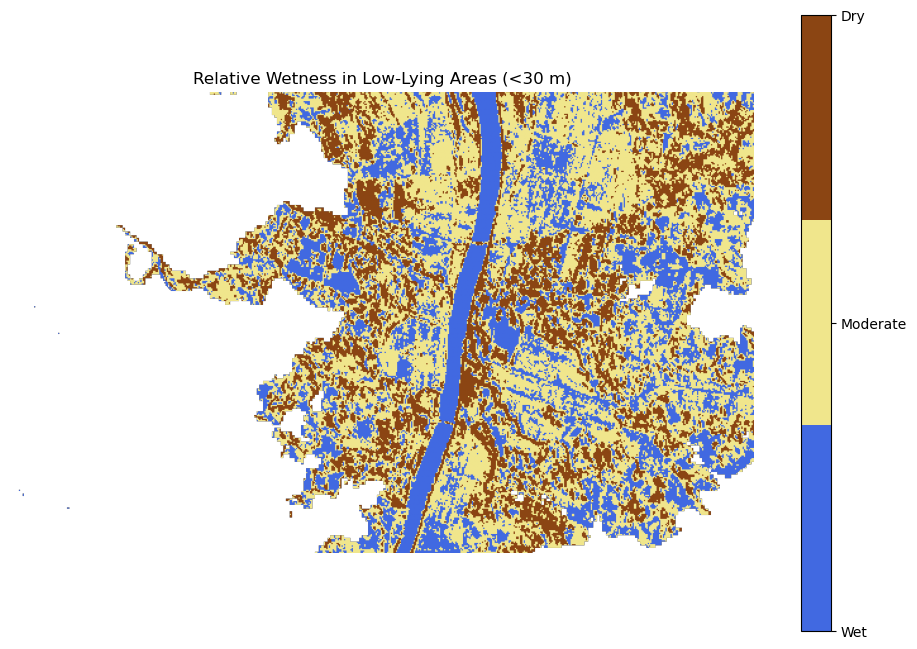

In [82]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "royalblue",   # Wet
    "khaki",       # Moderate
    "saddlebrown"  # Dry
])

plt.figure(figsize=(12,8))
plt.imshow(classification, cmap=cmap)

cbar = plt.colorbar()
cbar.set_ticks([1,2,3])
cbar.set_ticklabels(["Wet","Moderate","Dry"])

plt.title("Relative Wetness in Low-Lying Areas (<30 m)")
plt.axis("off")
plt.show()

## Calculate Soil Moisture Index

In [83]:
land_vv = vv_mean.where(~water_mask)

In [84]:
valid = land_vv.values[
    (~np.isnan(land_vv.values)) &
    (land_vv.values > 1)
]

vv_wet = np.percentile(valid, 25)
vv_dry = np.percentile(valid, 75)

In [85]:
smi = (land_vv - vv_dry) / (vv_wet - vv_dry)

In [86]:
smi = smi.clip(min=0, max=1)

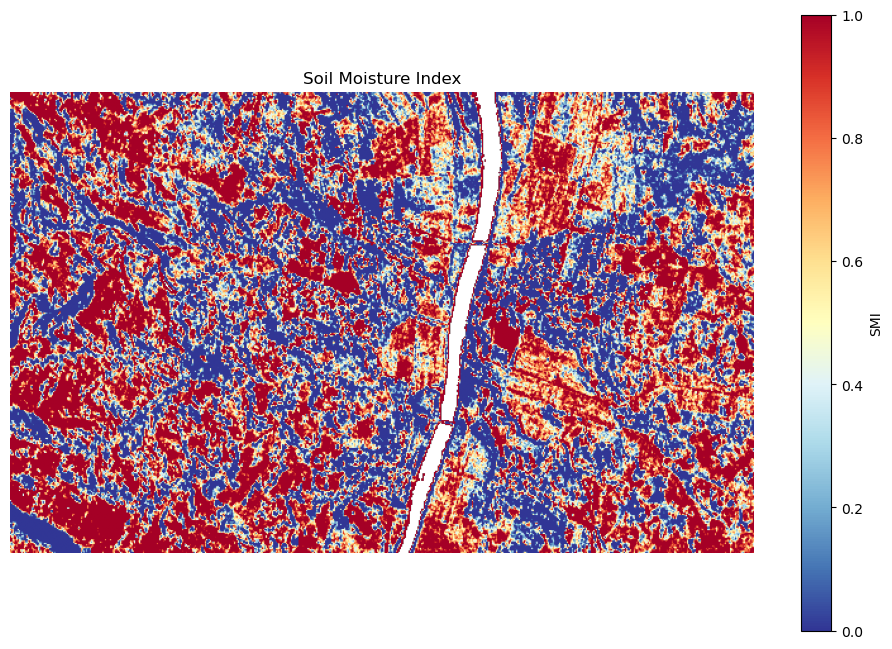

In [87]:
plt.figure(figsize=(12,8))

plt.imshow(
    smi,
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1
)

cbar = plt.colorbar()
cbar.set_label("SMI")

plt.title("Soil Moisture Index")
plt.axis("off")

plt.show()

In [108]:
# extract valid SMI values
smi_values = smi.values
valid_smi = smi_values[~np.isnan(smi_values)]

# summary statistics
print(f"Count   : {len(valid_smi):,}")
print(f"Minimum : {valid_smi.min():.3f}")
print(f"Maximum : {valid_smi.max():.3f}")
print(f"Mean    : {valid_smi.mean():.3f}")
print(f"Median  : {np.median(valid_smi):.3f}")
print(f"Std Dev : {valid_smi.std():.3f}")

# quartiles
print(f"25%     : {np.percentile(valid_smi, 25):.3f}")
print(f"50%     : {np.percentile(valid_smi, 50):.3f}")
print(f"75%     : {np.percentile(valid_smi, 75):.3f}")

Count   : 210,563
Minimum : 0.000
Maximum : 1.000
Mean    : 0.515
Median  : 0.546
Std Dev : 0.405
25%     : 0.000
50%     : 0.546
75%     : 1.000


In [91]:
print("NaN pixels:", np.isnan(smi_masked).sum())

NaN pixels: <xarray.DataArray 'vv' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=int64, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2021-04-22


In [93]:
print("Original valid pixels:",
      smi.notnull().sum().compute())

print("Masked valid pixels:",
      smi_masked.notnull().sum().compute())

Original valid pixels: <xarray.DataArray 'vv' ()> Size: 8B
array(210563)
Coordinates:
    spatial_ref  int32 4B 4326
Masked valid pixels: <xarray.DataArray 'vv' ()> Size: 8B
array(121675)
Coordinates:
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2021-04-22


### Soil Moisture Index (SMI) Map Interpretation

The Soil Moisture Index (SMI) map illustrates the spatial distribution of relative soil moisture conditions within the study area after applying a Digital Elevation Model (DEM) mask. Areas above the specified elevation threshold were excluded from the analysis to focus on low-lying terrain that is more susceptible to water accumulation and flooding.

The SMI was calculated using Sentinel-1 VV backscatter values according to:

\[
SMI = \frac{VV - VV_{dry}}{VV_{wet} - VV_{dry}}
\]

where:

- \(VV\) is the observed backscatter value,
- \(VV_{wet}\) represents the wet reference backscatter,
- \(VV_{dry}\) represents the dry reference backscatter.

The resulting SMI values range from 0 to 1:

- **SMI values close to 0** (dark purple) indicate relatively dry conditions.
- **SMI values close to 1** (yellow) indicate relatively wet conditions.
- **Intermediate values** (green to turquoise) represent moderate moisture conditions.

The map reveals substantial spatial variability in soil moisture across the floodplain. Areas with high SMI values are concentrated along low-lying zones and drainage pathways, indicating wetter soils with greater moisture retention. Conversely, areas with low SMI values correspond to drier surfaces with lower relative soil moisture.

The white areas visible in the map represent regions excluded from analysis through DEM masking or other preprocessing steps. These areas typically correspond to higher elevations that are less relevant to floodplain moisture assessment.

Overall, the SMI map highlights patterns of moisture distribution within the low-elevation landscape and demonstrates the utility of Sentinel-1 SAR data for identifying wet and dry conditions in support of flood monitoring and environmental assessment.

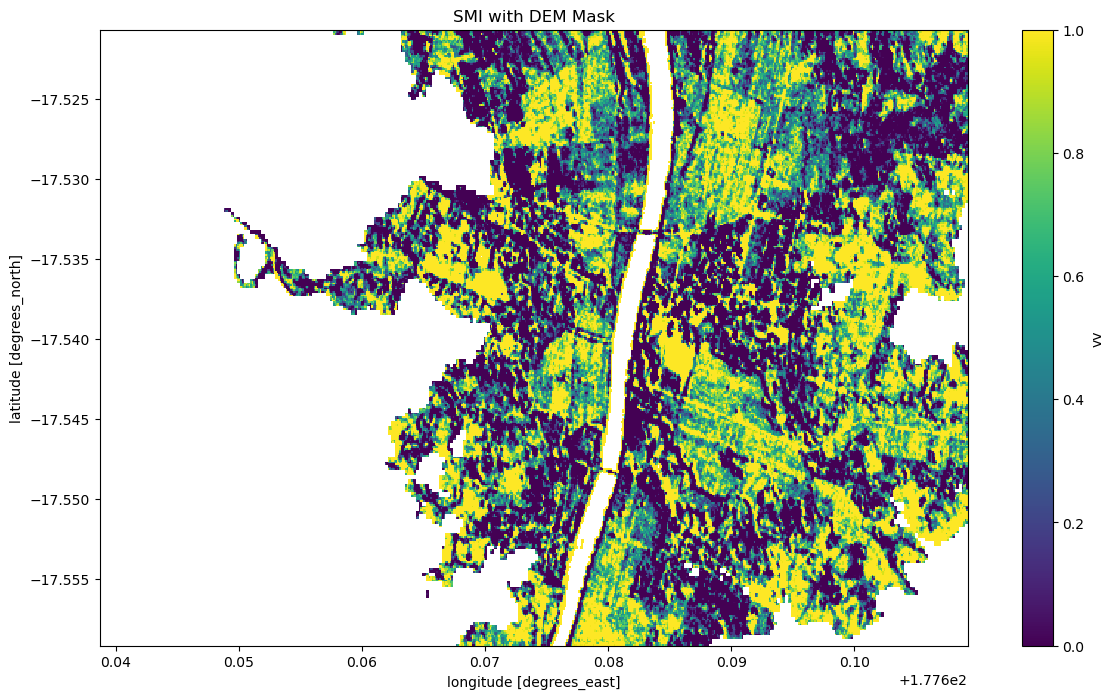

In [105]:
plt.figure(figsize=(14,8))
smi_masked.plot()
plt.title("SMI with DEM Mask")
plt.show()

### Interpretation of the Raw Soil Moisture Index (SMI)

The Raw Soil Moisture Index (SMI) was calculated using the equation:

\[
SMI = \frac{VV - VV_{dry}}{VV_{wet} - VV_{dry}}
\]

where:

- \(VV\) is the observed Sentinel-1 VV backscatter value,
- \(VV_{wet}\) is the wet reference backscatter,
- \(VV_{dry}\) is the dry reference backscatter.

Unlike the final SMI product, the raw SMI values were not constrained to the theoretical range of 0 to 1. As a result, values less than 0 and greater than 1 are retained, allowing assessment of how the observed backscatter compares with the selected wet and dry reference conditions.

### Statistical Summary

The raw SMI results show:

- **Values less than 0:** 52,640 pixels
- **Values between 0 and 1:** 105,282 pixels
- **Values greater than 1:** 52,641 pixels

This indicates that approximately half of the observations fall outside the theoretical 0-1 range, while the remaining pixels are distributed between the wet and dry reference conditions.



In [97]:
raw_smi = (land_vv - vv_dry) / (vv_wet - vv_dry)

raw_valid = raw_smi.values[~np.isnan(raw_smi.values)]

print("Less than 0:", np.sum(raw_valid < 0))
print("Greater than 1:", np.sum(raw_valid > 1))
print("Between 0 and 1:", np.sum((raw_valid >= 0) & (raw_valid <= 1)))

Less than 0: 52640
Greater than 1: 52641
Between 0 and 1: 105282


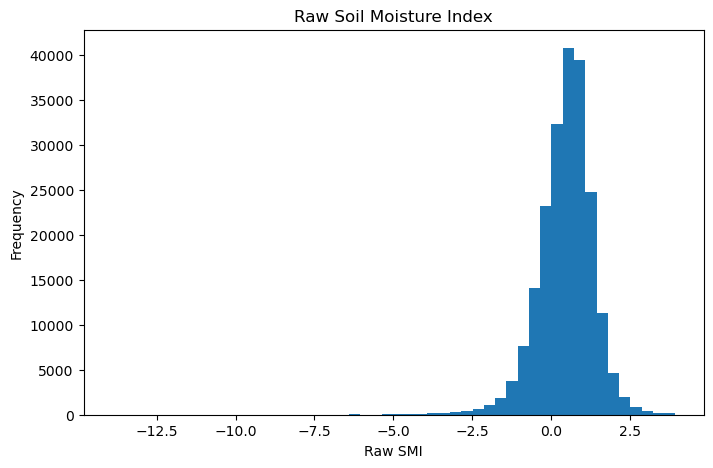

In [98]:
plt.figure(figsize=(8,5))
plt.hist(raw_valid, bins=50)
plt.xlabel("Raw SMI")
plt.ylabel("Frequency")
plt.title("Raw Soil Moisture Index")
plt.show()

### Interpretation of SMI Classes

#### SMI < 0
Pixels with negative SMI values have backscatter values lower than the selected dry reference value. These pixels may represent:

- Very dry surfaces,
- Areas with sparse vegetation,
- Local surface roughness effects,
- Residual SAR noise and speckle.

A total of **52,640 pixels** fall into this category.

#### 0 ≤ SMI ≤ 1
Pixels within this range represent moisture conditions bounded by the selected wet and dry reference values. These pixels are considered to have realistic relative moisture conditions ranging from dry to wet.

A total of **105,282 pixels** fall within this range.

#### SMI > 1
Pixels with SMI values greater than 1 have backscatter responses exceeding the selected wet reference value. These may correspond to:

- Saturated soils,
- Waterlogged surfaces,
- Flood-prone areas,
- Areas immediately adjacent to river channels and drainage networks.

A total of **52,641 pixels** fall into this category.

### Interpretation of the Histogram

The histogram displays a strongly unimodal distribution with a peak centred near **SMI = 0.5 to 1.0**. Most pixels are concentrated around this range, indicating that a large proportion of the study area exhibits moderate to high moisture conditions.

The distribution exhibits:

- A pronounced peak around intermediate moisture conditions.
- A left-skewed tail extending towards negative values.
- A smaller right tail extending beyond SMI values of 2.

The long negative tail suggests that some locations are substantially drier than the selected dry reference, whereas the positive tail suggests that some locations are wetter than the selected wet reference.

### Key Findings

- The majority of pixels are concentrated around moderate moisture conditions.
- Approximately **50% of pixels fall within the expected 0-1 SMI range**.
- Nearly equal numbers of pixels fall below 0 and above 1, indicating that the selected wet and dry reference values may be relatively restrictive.
- The distribution suggests substantial spatial variability in soil moisture across the low-lying floodplain.
- Areas represented by high SMI values are likely associated with wetter soils and potential moisture accumulation

In [102]:
import numpy as np
import matplotlib.pyplot as plt

smi_valid = smi_masked.values[~np.isnan(smi_masked.values)]

# SMI classes
dry = np.sum(smi_valid < 0.3)
moderate = np.sum((smi_valid >= 0.3) & (smi_valid <= 0.7))
wet = np.sum(smi_valid > 0.7)

total = len(smi_valid)

dry_pct = 100 * dry / total
moderate_pct = 100 * moderate / total
wet_pct = 100 * wet / total

# Print results
print("Soil Moisture Classes")
print("----------------------")
print(f"Wet Area (>0.7): {wet_pct:.2f}%")
print(f"Moderate Area (0.3-0.7): {moderate_pct:.2f}%")


Soil Moisture Classes
----------------------
Wet Area (>0.7): 36.75%
Moderate Area (0.3-0.7): 23.38%


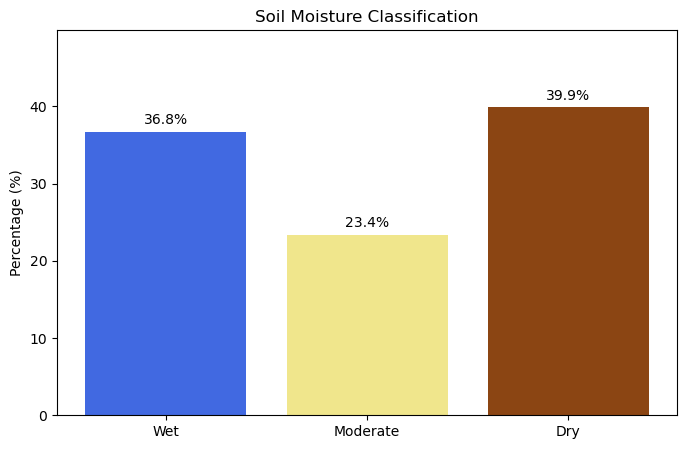

In [103]:
classes = ["Wet", "Moderate", "Dry"]
percentages = [wet_pct, moderate_pct, dry_pct]

colors = ["royalblue", "khaki", "saddlebrown"]

plt.figure(figsize=(8,5))

bars = plt.bar(classes, percentages, color=colors)

plt.ylabel("Percentage (%)")
plt.title("Soil Moisture Classification")

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0, max(percentages) + 10)

plt.show()

### Soil Moisture Classification Results

The bar chart summarizes the proportion of wet, moderate, and dry areas derived from the Soil Moisture Index (SMI) within the DEM-masked study area. The classification was based on the following thresholds:

- **Wet:** SMI > 0.7
- **Moderate:** 0.3 ≤ SMI ≤ 0.7
- **Dry:** SMI < 0.3

#### Results

- **Wet Areas:** 36.8%
- **Moderately Moist Areas:** 23.4%
- **Dry Areas:** 39.9%

#### Interpretation

The study area is predominantly characterized by **dry and wet conditions**, with relatively fewer areas exhibiting moderate moisture levels.

The **dry class (39.9%)** represents the largest proportion of the landscape, indicating that much of the floodplain and surrounding low-elevation land experienced relatively low soil moisture conditions during the Sentinel-1 acquisition period.

The **wet class (36.8%)** accounts for a substantial proportion of the study area, suggesting the presence of areas with elevated moisture content. These locations are likely associated with low-lying terrain, flood-prone zones, drainage pathways, and areas adjacent to river channels where water accumulation and soil saturation are more common.

The **moderate moisture class (23.4%)** occupies the smallest proportion of the study area. This indicates that soil moisture conditions tended to cluster toward either relatively wet or relatively dry states rather than intermediate conditions.

Overall, the results show a heterogeneous moisture environment, with approximately equal proportions of wet and dry areas. This variability reflects differences in topography, drainage characteristics, land cover, and proximity to surface water sources across the low-lying landscape. The findings demonstrate the ability of Sentinel-1 SAR-derived SMI to identify and quantify spatial patterns of soil moisture, supporting environmental monitoring and flood-related assessments.

In [106]:
#Export as tiff

In [107]:
import rioxarray

# Write CRS if needed
smi_masked = smi_masked.rio.write_crs("EPSG:4326")

# Export GeoTIFF
smi_masked.rio.to_raster("smi_dem_masked.tif")